In [1]:
### IMPORTS ###
import matplotlib.pyplot as plt
import os
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


In [ ]:
os.makedirs('results', exist_ok=True)


In [ ]:
### PARAMETROS ###

n_epochs = 50
batch_size_train = 64
batch_size_test = 1000
learning_rate = 0.001
momentum = 0.5
log_interval = 10

random_seed = 1
torch.backends.cudnn.enabled = False
torch.manual_seed(random_seed)

In [ ]:
### Dowload Dataset ###

train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('data', train=True, download=True,
                             transform=torchvision.transforms.Compose([ #aplica transformaçoes em sequencia 
                               torchvision.transforms.ToTensor(),       #transforma em tensor
                               torchvision.transforms.Normalize(        #normalizaçao estatistica (media, desvio padrao)
                                 (0.1307,), (0.3081,))                  #x_normalizado = (x − média) / desvio_padrão
                             ])),
  batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('data', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_test, shuffle=True)



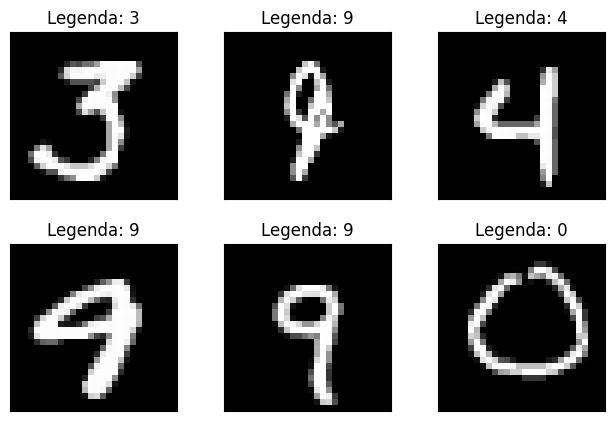

In [ ]:
### visualizaçao dos dados ###

examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

example_data.shape


fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Legenda: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])


In [ ]:
### criando Network ###

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5)
        self.conv2_drop = nn.Dropout2d() # desliga aleatoriamente um feature maps, evita overffiting
        self.fc1 = nn.Linear(512, 50) # reduz feature maps 
        self.fc2 = nn.Linear(50, 10) # saida, classifica digitos

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x),2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)),2))
        x = x.view(-1, 512)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = Net()
network.to(device)
optimizer = optim.SGD(network.parameters(), lr=learning_rate, momentum=momentum)

In [ ]:
### check parametros ###

train_losses = []
train_counter = []
test_losses = []
test_counter = [i*len(train_loader.dataset) for i in range(n_epochs + 1)]

In [ ]:
### treino ###

def train(epoch):
  network.train() #ativa modo treino
  for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device) 
    optimizer.zero_grad() # limpa os gradientes
    output = network(data)
    loss = F.nll_loss(output, target) # calculo de erro, Negative Log Likelihood Loss, funciona com o softmax
    loss.backward() # backpropagation
    optimizer.step() # os pesos são atualizados
    if batch_idx % log_interval == 0:
      # print('Train Epoch: {}\tLoss: {:.6f}'.format(
      #   epoch, loss.item()))
      train_losses.append(loss.item()) #salva valor da loss
      train_counter.append(
        (batch_idx*64) + ((epoch-1)*len(train_loader.dataset)))
      torch.save(network.state_dict(), 'results/model.pth')
      torch.save(optimizer.state_dict(), 'results/optimizer.pth')

In [ ]:
### Teste function ###

def test(epoch):
  network.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      data, target = data.to(device), target.to(device)
      output = network(data)
      test_loss += F.nll_loss(output, target, size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  test_loss /= len(test_loader.dataset)
  test_losses.append(test_loss)
  print('\nTest set: Epoch:{} Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    epoch, test_loss, correct, len(test_loader.dataset),
    100. * correct / len(test_loader.dataset)))

In [ ]:
for epoch in range(n_epochs):
    train(epoch)
    test(epoch)

c:\Users\Admin\Desktop\TCC\MNIST\venv\Lib\site-packages\torch\nn\functional.py:3178: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  reduction = _Reduction.legacy_get_string(size_average, reduce)



Test set: Epoch:0 Avg. loss: 1.4308, Accuracy: 7400/10000 (74%)


Test set: Epoch:1 Avg. loss: 0.5416, Accuracy: 8693/10000 (87%)


Test set: Epoch:2 Avg. loss: 0.3567, Accuracy: 9071/10000 (91%)


Test set: Epoch:3 Avg. loss: 0.2876, Accuracy: 9229/10000 (92%)


Test set: Epoch:4 Avg. loss: 0.2453, Accuracy: 9310/10000 (93%)


Test set: Epoch:5 Avg. loss: 0.2150, Accuracy: 9376/10000 (94%)


Test set: Epoch:6 Avg. loss: 0.1909, Accuracy: 9441/10000 (94%)


Test set: Epoch:7 Avg. loss: 0.1732, Accuracy: 9507/10000 (95%)


Test set: Epoch:8 Avg. loss: 0.1582, Accuracy: 9540/10000 (95%)


Test set: Epoch:9 Avg. loss: 0.1477, Accuracy: 9566/10000 (96%)


Test set: Epoch:10 Avg. loss: 0.1406, Accuracy: 9578/10000 (96%)


Test set: Epoch:11 Avg. loss: 0.1286, Accuracy: 9612/10000 (96%)


Test set: Epoch:12 Avg. loss: 0.1215, Accuracy: 9639/10000 (96%)


Test set: Epoch:13 Avg. loss: 0.1165, Accuracy: 9646/10000 (96%)


Test set: Epoch:14 Avg. loss: 0.1115, Accuracy: 9659/10000 (97%)


Test

In [ ]:
# ### avaliando a performance ###

# fig = plt.figure()
# plt.plot(train_counter, train_losses, color='blue')
# plt.scatter(test_counter, test_losses, color='red')
# plt.legend(['Train Loss', 'Test Loss'], loc='upper right')
# plt.xlabel('number of training examples seen')
# plt.ylabel('negative log likelihood loss')
